In [2]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-01-28 17:18:52.874620


In [3]:
from pathlib import Path
import sys
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.colors as clr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import seaborn as sns

In [4]:
plt.rcdefaults()

In [5]:
# make text editable as words in output plots
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

In [6]:


base_dir = "/home/workspace/DRG"
data_dir = "sc-spatial-gpu-ide_transer/projects/20260115_drg-gpu-backup"

output_dir = os.path.join(base_dir, "spatial_mouse_drg_outputs/Kim/update_thresholds")

plot_out_dir = os.path.join(output_dir, "plots_labeling_walkthrough")
if not os.path.exists (plot_out_dir):
    os.makedirs(plot_out_dir)

# ginty reference in MC private folder
adata_ginty_path_00 = "/home/workspace/DRG/MC_private_folder/home/workspace/private/projects/kim/drg/data/scrna-seq/h5ad/04_clustered/GSE139088-scvi-leiden.h5ad"

# global scvi umap: output from spatial_mouse_drg/notebooks/02_integration/02_clustering.ipynb 
adata_480_path_01 = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_02/02b_leiden/adata-leiden-480.h5ad"

# merged labels: output from spatial_mouse_drg/notebooks/03_cell-labels/05_merge-annotations.ipynb
adata_merged_labels_path_02 = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_03/03b_seurat/adata-merged-labels.h5ad"

# cannot locate this one
# # after MC guassian thresholding: output from spatial_mouse_drg/notebooks/03_cell-labels/06_gaussian-fit.ipynb
# adata_labeled_path_03 = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_03/03c_thresholds/adata-labeled.h5ad"

# neuron subclustered from scvi on seurat dims: ouput from spatial_mouse_drg/notebooks/05_neurons/02_recluster-neurons.ipynb
adata_neurons_seurat_path_04 = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_04/04b_reclustered/neurons-seurat.h5ad"

# final labeled object after neuron labeling of subclusters and the cgrp-gamma split: output from spatial_mouse_drg/notebooks/05_neurons/03_split-cgrp-gamma.ipynb
adata_path_05  = "/home/workspace/DRG/sc-spatial-gpu_ide_transfer/projects/20260115_drg-gpu-backup/data/h5ad/export_04/04c_gamma_subtypes/neurons-final-labels.h5ad"



In [7]:
# load all adata

# reference
adata_ginty_00 = sc.read_h5ad(adata_ginty_path_00)

# xenium 
adata_global_480_01 = sc.read_h5ad(adata_480_path_01)
adata_global_labeled_02 = sc.read_h5ad(adata_merged_labels_path_02)
# adata_global_labeled_03 = sc.read_h5ad(adata_labeled_path_03)
adata_neuron_seurat_04 = sc.read_h5ad(adata_neurons_seurat_path_04)
adata_neuron_final_05 = sc.read_h5ad(adata_path_05)

In [8]:
adata_list = [adata_global_480_01, adata_global_labeled_02, adata_neuron_seurat_04, adata_neuron_final_05]
for adata in adata_list:
    min_counts = min(adata.obs['total_counts'])
    print(adata.shape)
    print(f"min counts: {min_counts}")
    # print(adata.obs.head(1))

(147036, 480)
min counts: 51.0
(147036, 475)
min counts: 51.0
(22411, 475)
min counts: 1000.0
(22411, 475)
min counts: 1000.0


In [9]:
# remove the barcode suffixes from adata-480 to match the rest
adata_global_480_01

index_clipped = ["-".join(barcode.split('-')[0:2]) for barcode in adata_global_480_01.obs.index]
adata_global_480_01.obs.index = index_clipped

## Plotting functions

In [10]:
import matplotlib.pyplot as plt

def plot_umaps(
    adata,
    label_cols,
    true_color_map,
    false_color,
    true_size,
    false_size,
    edgecolor,
    linewidth,
    alpha_false,
    alpha_true,
    figsize=(3, 3),
    save_path  = None
):
    """
    Plot minimalist UMAPs for boolean label columns.
    No title, no axes, no border.
    """

    if "X_umap" not in adata.obsm:
        raise ValueError("No UMAP found in adata.obsm['X_umap'].")

    x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

    for col in label_cols:
        if col not in adata.obs.columns:
            print(f"Column `{col}` not in adata.obs — skipping.")
            continue

        if col not in true_color_map:
            raise ValueError(f"Missing true_color_map entry for `{col}`.")

        true_color = true_color_map[col]
        mask = adata.obs[col].astype(bool).values

        plt.figure(figsize=figsize)

        # Plot FALSE background
        plt.scatter(
            x[~mask],
            y[~mask],
            s=false_size,
            c=false_color,
            linewidths=0,
            alpha=alpha_false,
        )

        # Plot TRUE foreground
        plt.scatter(
            x[mask],
            y[mask],
            s=true_size,
            c=true_color,
            linewidths=linewidth,
            edgecolors=edgecolor,
            alpha=alpha_true,
        )

        ax = plt.gca()
        ax.set_aspect("equal", "box")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")  # remove title
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()

        if save_path is not None:
            plt.savefig(os.path.join(save_path, f"umap_{col}.pdf"), format='pdf', bbox_inches='tight')

        plt.show()

In [11]:
def barplot_dual_distribution(
    adata,
    population_name,
    group_col="neuron_labels",
    dual_col="EGFP_dTomato_dual_hi",
    bar_color="black",
    figsize=(4, 4),
    fontsize=11,
    plot_counts = True,
    return_group_order=False,
    group_order=None,
):
    df = adata.obs[[group_col, dual_col]].copy()
    df[dual_col] = df[dual_col].astype(bool)
    df[group_col] = df[group_col].astype(str).replace("nan", "Unknown")

    # Count dual positives per group (correct)
    dual_counts = df.groupby(group_col)[dual_col].sum()

    total_dual = dual_counts.sum()
    print('number +: ', total_dual)

    # percentage
    stats = (dual_counts / total_dual * 100).sort_values(ascending=False)

    if group_order is not None:
        # Use the provided order. .reindex ensures we handle missing/extra groups safely.
        # Fill missing groups with 0 so the bars show up as empty instead of crashing.
        stats = stats.reindex(group_order).fillna(0)
    else:
        # Default: Sort by percentage descending
        stats = stats.sort_values(ascending=False)
    
    # Final order of categories
    final_order = stats.index.tolist()
    sorted_counts = dual_counts.reindex(final_order).fillna(0)

    # # ordered counts
    # sorted_counts = dual_counts.loc[stats.index]

    fig, ax = plt.subplots(figsize=figsize)

    x = np.arange(len(stats))
    if plot_counts:
        ax.bar(x, sorted_counts.values, color=bar_color, alpha=0.9)
    else:
        ax.bar(x, stats.values, color=bar_color, alpha=0.9)

    # xticks
    ax.set_xticks(x)
    ax.set_xticklabels(stats.index, rotation=45, ha="right", fontsize=fontsize)

    # y-axis
    if plot_counts:
        ax.set_ylabel("Count", fontsize=fontsize)
    else:     
        ax.set_ylim(0, 100)  # <-- force axis to show full 0–100%
        ax.set_ylabel(f"% of {population_name} \nneurons", fontsize=fontsize)
    ax.set_xlabel("")

    # minimalist styling
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="y", length=0)
    ax.tick_params(axis="x", length=0)

    plt.subplots_adjust(bottom=0.28)
    if return_group_order:
        return fig, final_order
    return fig

## Umaps

In [12]:
adata_list = [adata_global_480_01, adata_global_labeled_02, adata_neuron_seurat_04, adata_neuron_final_05]

In [20]:
for adata in adata_list:
    print(adata.shape)
    print(min(adata.obs['total_counts']))

(147036, 480)
51.0
(147036, 475)
51.0
(22411, 475)
1000.0
(22411, 475)
1000.0


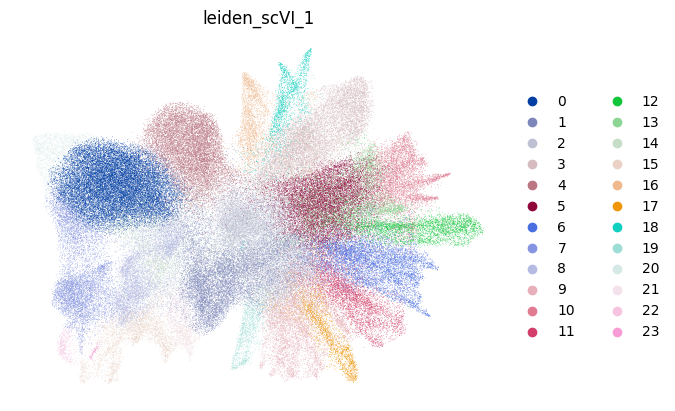

In [22]:
sc.pl.embedding(adata_global_480_01, basis = 'X_umap', color = 'leiden_scVI_1', frameon=False)

In [15]:
adata_global_labeled_02

AnnData object with n_obs × n_vars = 147036 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predict

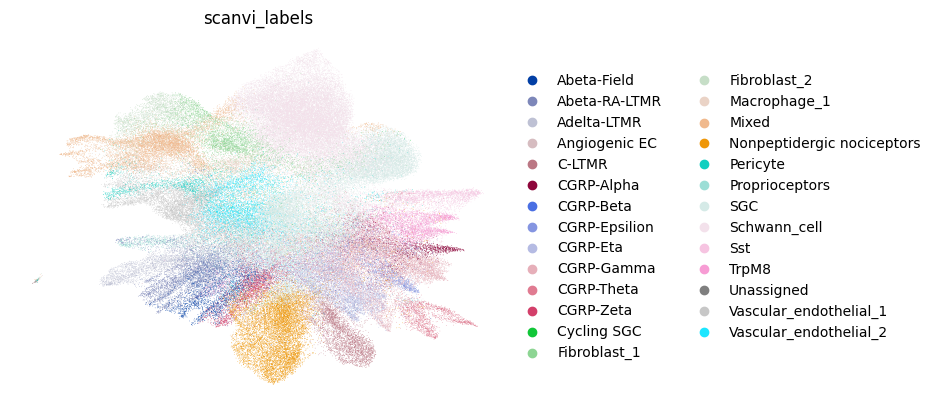

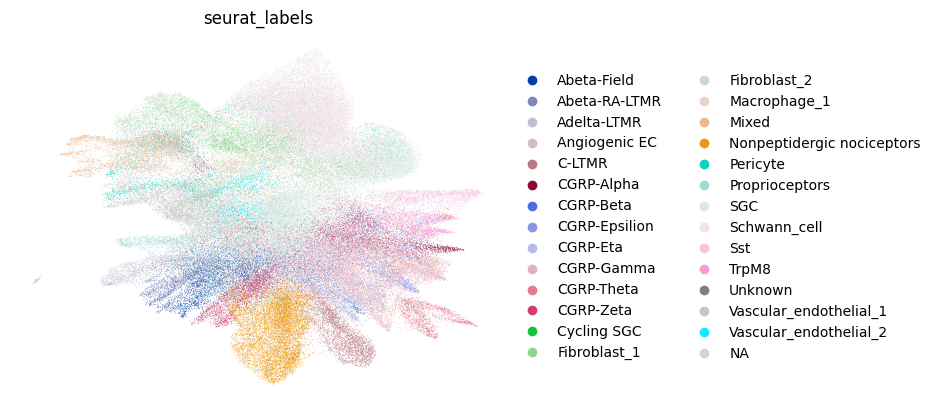

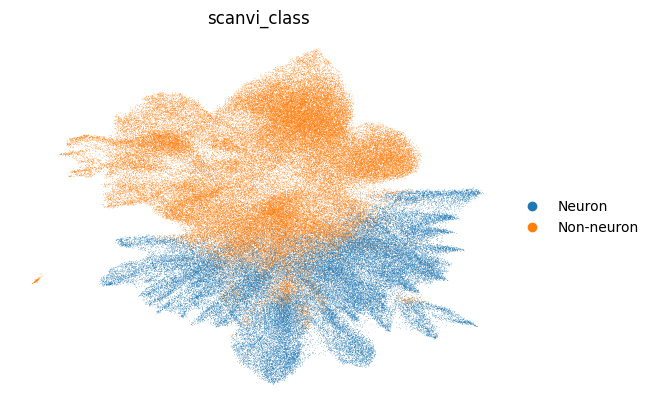

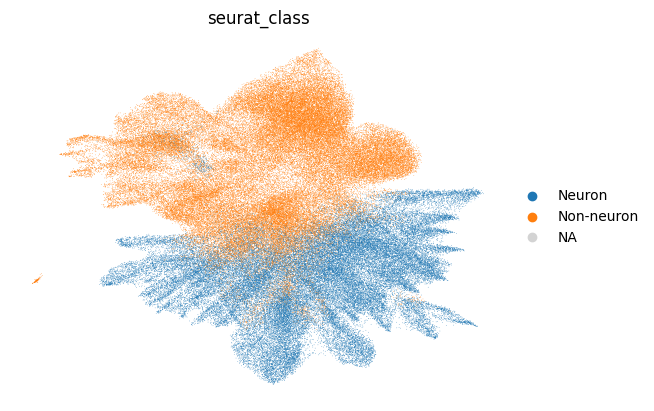

In [19]:
sc.pl.embedding(adata_global_labeled_02, basis = 'X_umap', color = 'scanvi_labels', frameon=False)
sc.pl.embedding(adata_global_labeled_02, basis = 'X_umap', color = 'seurat_labels', frameon=False)

sc.pl.embedding(adata_global_labeled_02, basis = 'X_umap', color = 'scanvi_class', frameon=False)
sc.pl.embedding(adata_global_labeled_02, basis = 'X_umap', color = 'seurat_class', frameon=False)

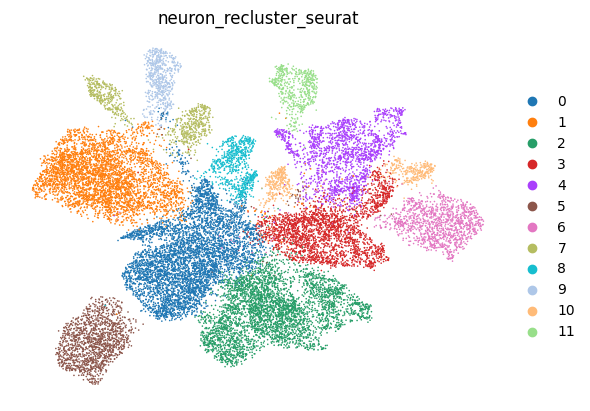

In [27]:
sc.pl.embedding(adata_neuron_seurat_04, basis = 'X_umap', color = 'neuron_recluster_seurat', frameon=False)

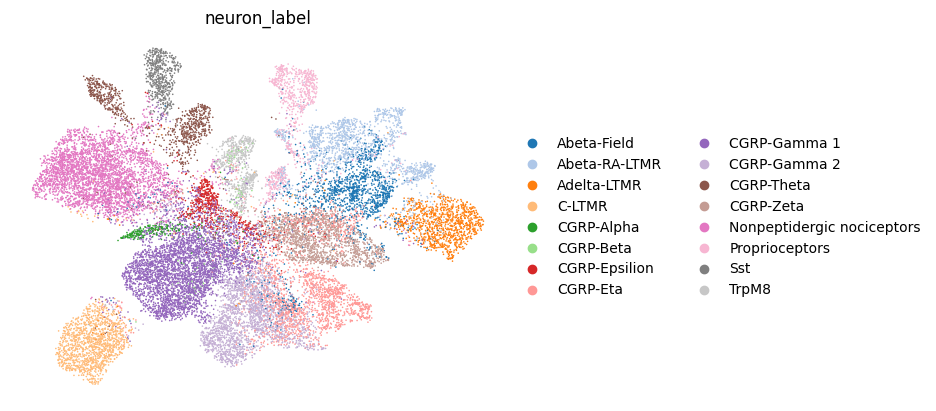

In [29]:
sc.pl.embedding(adata_neuron_final_05, basis = 'X_umap', color = 'neuron_label', frameon=False)

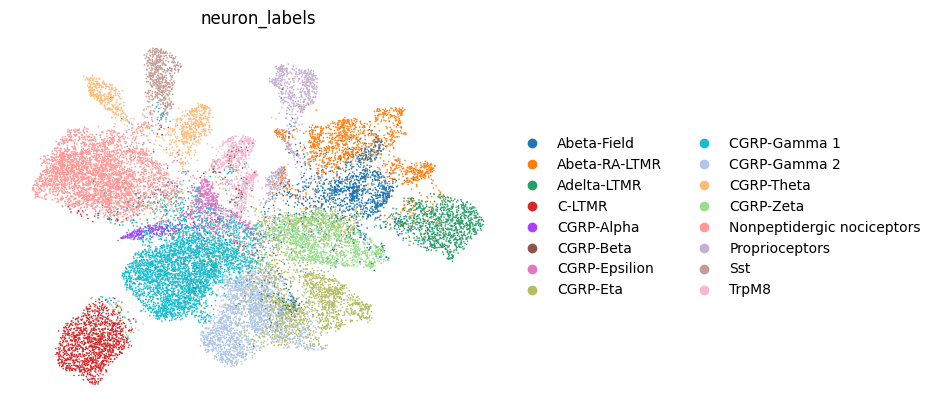

In [30]:
sc.pl.embedding(adata_neuron_final_05, basis = 'X_umap', color = 'neuron_labels', frameon=False)

## Closer look at neuron vs non neuron classification

In [32]:
# add the neuron final labels to the global umap to see where they show up
adata_global_labeled_02.obs = adata_global_labeled_02.obs.join(adata_neuron_final_05.obs[['neuron_label']])

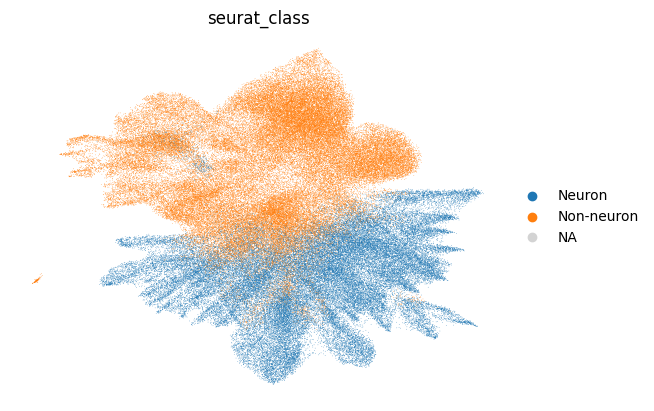

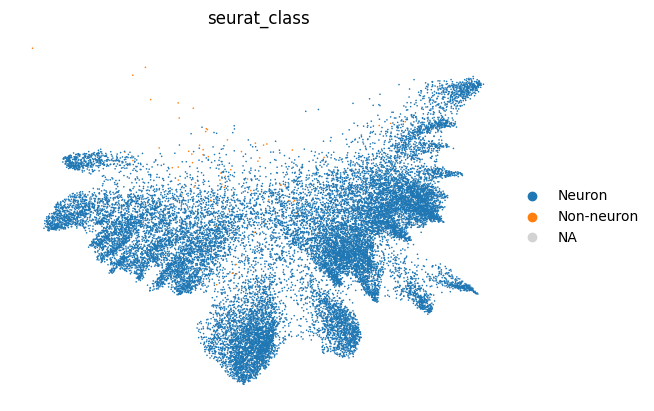

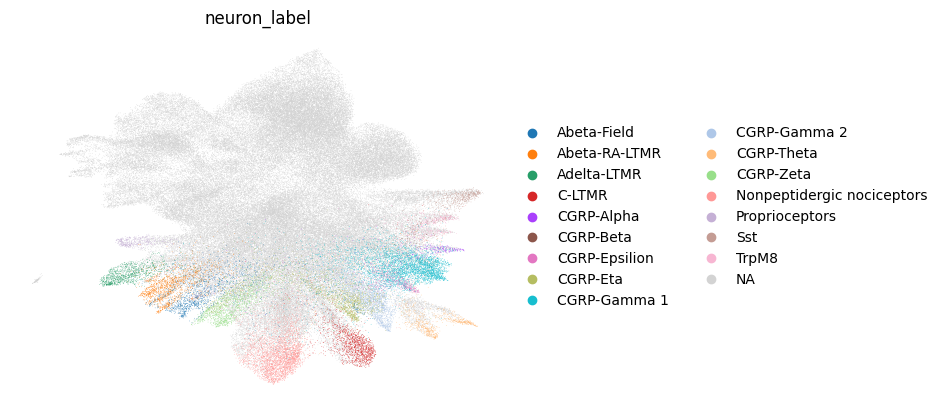

In [33]:
sc.pl.embedding(adata_global_labeled_02, basis = 'X_umap', color = 'seurat_class', frameon=False)
sc.pl.embedding(adata_global_labeled_02[adata_global_labeled_02.obs['total_counts']>1000, :], basis = 'X_umap', color = 'seurat_class', frameon=False)
sc.pl.embedding(adata_global_labeled_02, basis = 'X_umap', color = 'neuron_label', frameon=False)

In [ ]:
## Identify the Abeta-RA-LTMR barcodes that are showing up as EGFP+ and see where they are on both the global and neuron umaps